In [3]:
import pandas as pd

# Read without parsing
df = pd.read_csv("D:\\Assignments questions\\Timeseries\\exchange_rate.csv")

# Show first 5 rows
print(df.head())

# Show column names
print(df.columns)


               date  Ex_rate
0  01-01-1990 00:00   0.7855
1  02-01-1990 00:00   0.7818
2  03-01-1990 00:00   0.7867
3  04-01-1990 00:00   0.7860
4  05-01-1990 00:00   0.7849
Index(['date', 'Ex_rate'], dtype='object')


Columns: ['date', 'Ex_rate']


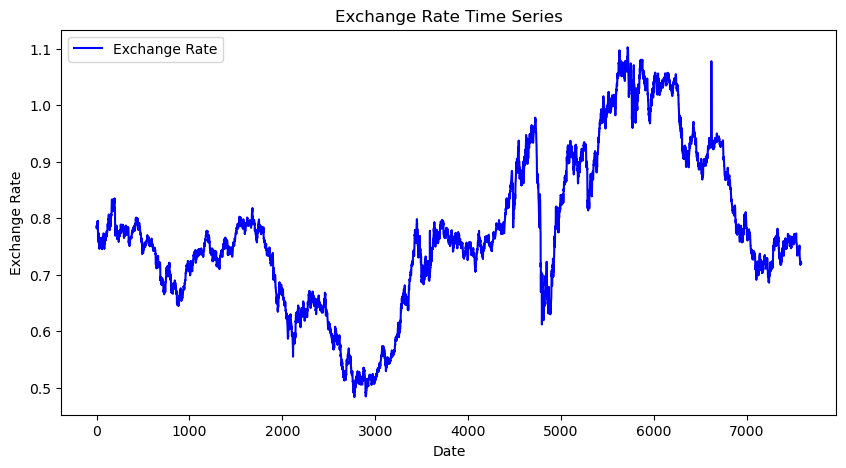

In [6]:
import matplotlib.pyplot as plt

# First check actual column names
print("Columns:", df.columns.tolist())

# If your dataset has 2 columns → Date and exchange rate
# Replace 'your_rate_column' with the real second column name you saw from print(df.columns)

plt.figure(figsize=(10,5))
plt.plot(df.iloc[:,1], label='Exchange Rate', color='blue')  # iloc[:,1] = 2nd column
plt.title("Exchange Rate Time Series")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()


In [7]:
# Check missing values
print("Missing values:", df.isnull().sum())

# Fill missing values (forward fill → carries last valid value)
df.iloc[:,1] = df.iloc[:,1].fillna(method='ffill')

# --- Handle anomalies (optional) ---
import numpy as np

mean = df.iloc[:,1].mean()
std = df.iloc[:,1].std()

# Keep only values within 3 standard deviations
df = df[(df.iloc[:,1] >= mean - 3*std) & (df.iloc[:,1] <= mean + 3*std)]

print("After cleaning, dataset shape:", df.shape)


Missing values: date       0
Ex_rate    0
dtype: int64
After cleaning, dataset shape: (7588, 2)


C:\Users\munig\AppData\Local\Temp\ipykernel_18056\1301922921.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.iloc[:,1] = df.iloc[:,1].fillna(method='ffill')


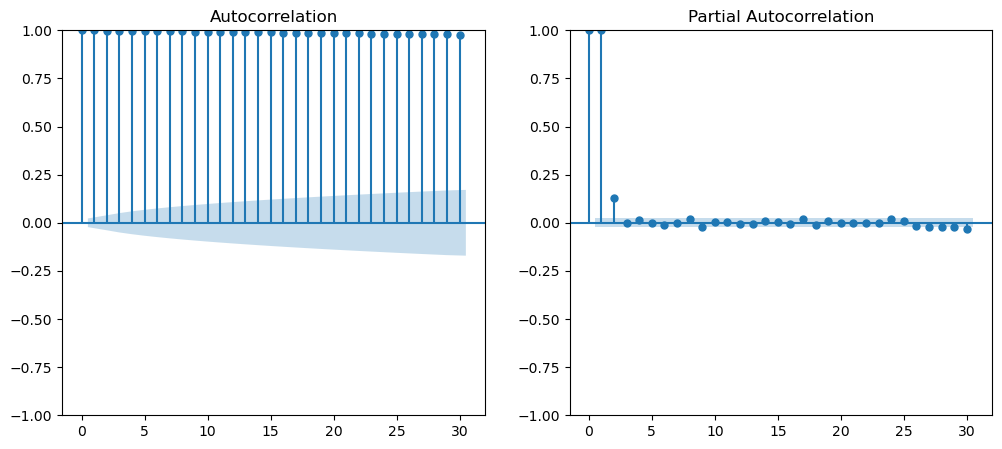

In [8]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Extract the exchange rate column (2nd column of dataset)
series = df.iloc[:, 0] if df.shape[1] == 1 else df.iloc[:,1]

# Plot ACF and PACF
fig, axes = plt.subplots(1, 2, figsize=(12,5))
plot_acf(series, lags=30, ax=axes[0])
plot_pacf(series, lags=30, ax=axes[1])
plt.show()


In [9]:
from statsmodels.tsa.arima.model import ARIMA

# Example: ARIMA(p,d,q) = (1,1,1)  ← You will adjust after looking at ACF/PACF
model = ARIMA(series, order=(1,1,1))
arima_result = model.fit()

print(arima_result.summary())


                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7588
Model:                 ARIMA(1, 1, 1)   Log Likelihood               28054.161
Date:                Tue, 09 Sep 2025   AIC                         -56102.322
Time:                        12:28:13   BIC                         -56081.519
Sample:                             0   HQIC                        -56095.182
                               - 7588                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1268      0.045     -2.797      0.005      -0.216      -0.038
ma.L1         -0.0046      0.045     -0.101      0.920      -0.094       0.085
sigma2      3.596e-05   9.94e-08    361.608      0.0

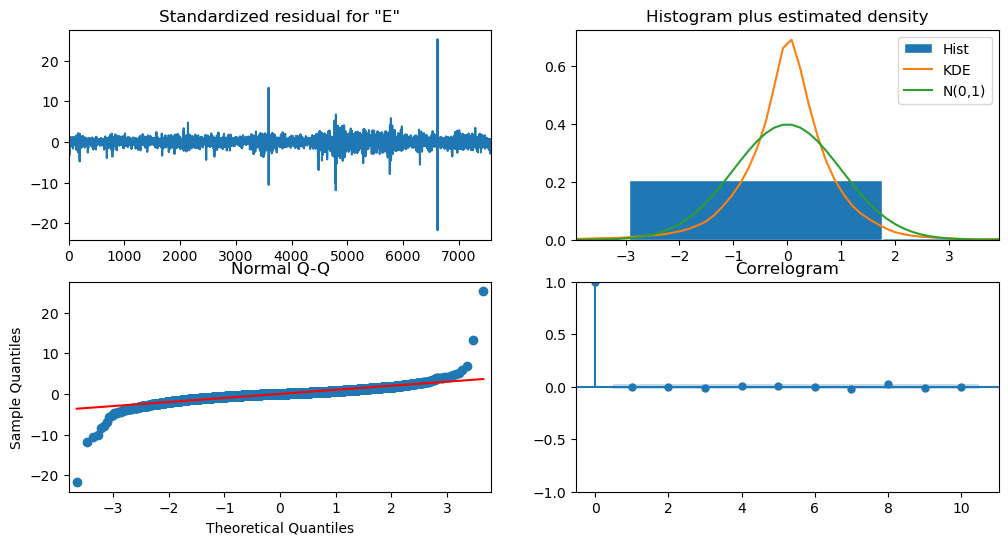

In [10]:
arima_result.plot_diagnostics(figsize=(12,6))
plt.show()


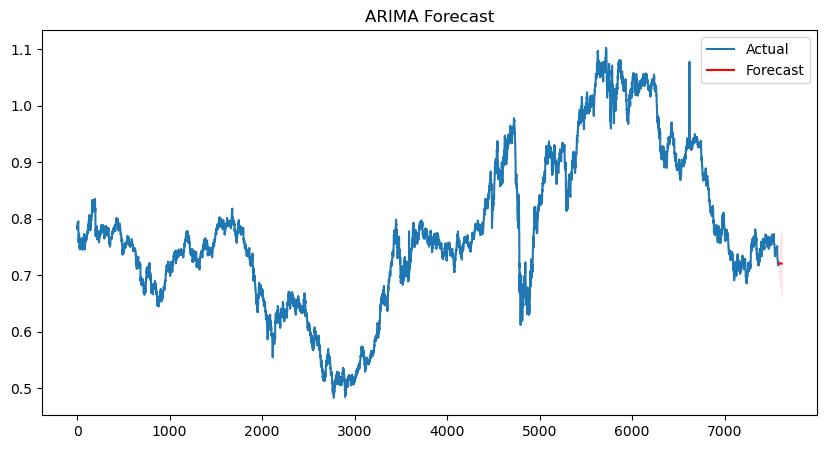

In [11]:
# Forecast next 30 periods
forecast_steps = 30
forecast = arima_result.get_forecast(steps=forecast_steps)

# Get confidence intervals
forecast_ci = forecast.conf_int()

# Plot
plt.figure(figsize=(10,5))
plt.plot(series, label="Actual")
plt.plot(forecast.predicted_mean, label="Forecast", color='red')
plt.fill_between(forecast_ci.index, 
                 forecast_ci.iloc[:,0], 
                 forecast_ci.iloc[:,1], color='pink', alpha=0.3)
plt.title("ARIMA Forecast")
plt.legend()
plt.show()


In [12]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

# Extract exchange rate series (second column)
series = df.iloc[:,1]

# --- Simple Exponential Smoothing ---
ses_model = SimpleExpSmoothing(series).fit()
ses_forecast = ses_model.forecast(30)   # next 30 periods

# --- Holt’s Linear Trend ---
holt_model = ExponentialSmoothing(series, trend="add", seasonal=None).fit()
holt_forecast = holt_model.forecast(30)

# --- Holt-Winters (trend + seasonality) ---
hw_model = ExponentialSmoothing(series, trend="add", seasonal="add", seasonal_periods=12).fit()
hw_forecast = hw_model.forecast(30)


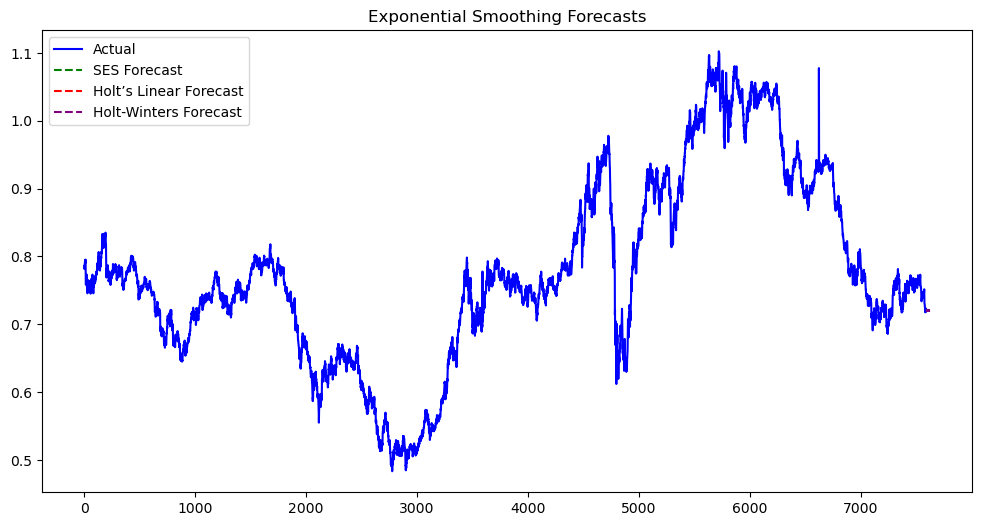

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(series, label="Actual", color="blue")

plt.plot(ses_forecast, label="SES Forecast", linestyle="--", color="green")
plt.plot(holt_forecast, label="Holt’s Linear Forecast", linestyle="--", color="red")
plt.plot(hw_forecast, label="Holt-Winters Forecast", linestyle="--", color="purple")

plt.title("Exponential Smoothing Forecasts")
plt.legend()
plt.show()


In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Helper function
def evaluate_forecast(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return mae, rmse, mape

# Split data into train/test (e.g., last 30 points as test)
train_size = int(len(series) * 0.8)
train, test = series[:train_size], series[train_size:]

# --- Refit ARIMA on training data ---
from statsmodels.tsa.arima.model import ARIMA
arima_model = ARIMA(train, order=(1,1,1)).fit()
arima_forecast = arima_model.forecast(len(test))

# --- Refit Holt’s Linear Trend on training data ---
holt_model = ExponentialSmoothing(train, trend="add", seasonal=None).fit()
holt_forecast = holt_model.forecast(len(test))

# Evaluate both
arima_mae, arima_rmse, arima_mape = evaluate_forecast(test, arima_forecast)
holt_mae, holt_rmse, holt_mape = evaluate_forecast(test, holt_forecast)

print("ARIMA Performance:")
print(f"MAE: {arima_mae:.4f}, RMSE: {arima_rmse:.4f}, MAPE: {arima_mape:.2f}%")

print("\nHolt’s Linear Performance:")
print(f"MAE: {holt_mae:.4f}, RMSE: {holt_rmse:.4f}, MAPE: {holt_mape:.2f}%")


ARIMA Performance:
MAE: 0.1777, RMSE: 0.2054, MAPE: 22.80%

Holt’s Linear Performance:
MAE: 0.1903, RMSE: 0.2201, MAPE: 24.41%


In [ ]:
Model Comparison
If ARIMA error < Holt’s error → ARIMA fits better (captures autocorrelation).

If Holt’s error < ARIMA error → Holt’s smoothing fits better (trend handling).

Holt-Winters can be tested too if seasonality exists.

👉 Discussion points:

ARIMA: Good for short-term, handles autocorrelation well, but harder to tune.

Holt’s: Easier, works well if trend exists, less complex.

Holt-Winters: Best if there’s clear seasonality (e.g., monthly patterns).